In [18]:
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import sys
sys.path.append("../code")
from load_dataset import load_population

import matplotlib as mpl
def set_rcParams():
    mpl.rcParams["axes.spines.right"] = False
    mpl.rcParams["axes.spines.top"] = False
    mpl.rcParams["axes.titlesize"]= 8
    mpl.rcParams["xtick.labelsize"] = 8
    mpl.rcParams["ytick.labelsize"] = 8
    mpl.rcParams["axes.labelsize"] = 10
    mpl.rcParams["legend.fontsize"] = 10
    mpl.rcParams["legend.title_fontsize"] = 10
    return None
plt.rcParams['text.usetex'] = True
set_rcParams()
cm = 1/2.54


ccolors = ['darkorange', 'green', 'blue', 'red', 'black']
countries_colors = {
    'Sweden': ccolors[2],
    'Denmark': ccolors[2],
    'Finland': ccolors[2],
    'Norway': ccolors[2],

    'Austria': ccolors[1],
    'Belgium': ccolors[1],
    'France': ccolors[1],
    'Germany': ccolors[1],
    'Luxembourg': ccolors[1],
    'Luxembourg*': ccolors[1],
    'United Kingdom': ccolors[1],
    'Switzerland': ccolors[1],
    'Netherlands': ccolors[1],

    'Greece': ccolors[1],
    'Italy': ccolors[1],
    'Portugal': ccolors[1],
    'Spain': ccolors[1],

    'Cyprus': ccolors[0],
    'Malta': ccolors[0],
    'Iceland': ccolors[0],
    'Ireland': ccolors[0],
    'Ireland*': ccolors[0],

    'Albania': ccolors[3],
    'Bulgaria': ccolors[3],
    'Czechia': ccolors[3],
    'Croatia': ccolors[3],
    'Estonia': ccolors[3],
    'Poland': ccolors[3],
    'Romania': ccolors[3],
    'Serbia': ccolors[3],
    'Slovakia': ccolors[3],
    'Slovenia': ccolors[3],
    'Montenegro': ccolors[3],
    'Latvia': ccolors[3],
    'Lithuania': ccolors[3],
    'Hungary': ccolors[3],
    'North Macedonia': ccolors[3],
    'North Macedonia*': ccolors[3],

    'Europe**': ccolors[4],
}


colors1 = sns.color_palette("colorblind", n_colors=4)
colors1 = sns.color_palette([colors1[1], colors1[0], colors1[2], colors1[3]])
colors2 = sns.color_palette(['blue', 'red', 'green', colors1[0]])
colors1 = sns.color_palette("colorblind", n_colors=4)
colors = colors1
colors


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0)]

### CIFR

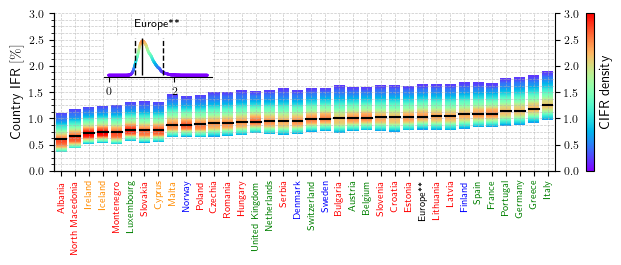

In [19]:
CIFR = pd.read_csv(f'../results/CIFRVectors.csv', index_col=0).T
CIFR_MEDIAN = pd.read_csv(f'../data/CIFRMedian.csv', index_col=0)
CIFR_MEDIAN = CIFR_MEDIAN.loc[CIFR.index, :]
ci = 0.975
CIFR = CIFR[~CIFR.index.str.contains('Liechtenstein')]
CIFR_MEDIAN = CIFR_MEDIAN[~CIFR_MEDIAN.index.str.contains('Liechtenstein')]
df = pd.DataFrame(columns=['Lower bound', 'Mean', 'Upper bound'], index=CIFR.index)

hist_bins = 500
hist_range = (0, 3)
fig, ax = plt.subplots(1, 1, figsize=(18.4*cm,7*cm))

cmap = plt.cm.rainbow

norm = mcolors.Normalize(vmin=0, vmax=2.5) # vmax is empirical based on the data

for i, country in enumerate(CIFR_MEDIAN.sort_values('Median').index):
    cifr = CIFR.loc[country, :]

    kde = gaussian_kde(cifr)
    bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
    hist_values = kde(bin_edges)
    hist_values_normalized = norm(hist_values)

    lower_bound = cifr.quantile(1 - ci)
    upper_bound = cifr.quantile(ci)
    for j in range(hist_bins):
        if bin_edges[j] > upper_bound:
            break
        if bin_edges[j] < lower_bound:
            continue
        ax.bar(
            i, 
            bin_edges[j + 1] - bin_edges[j],
            bottom=bin_edges[j],
            width=0.8, 
            color=cmap(hist_values_normalized[j]),
            edgecolor='none',
            align='center',
            )
    
    mean = cifr.mean()
    median = cifr.median()
    lower_bound = cifr.quantile(1 - ci)
    upper_bound = cifr.quantile(ci)
    ax.plot(
        [i - 0.35, i + 0.35],
        [CIFR_MEDIAN.loc[country, 'Median'], CIFR_MEDIAN.loc[country, 'Median']],
        color='black',
        linestyle='-',
        )


ax.set_xlabel('')
ax.set_ylabel(r'Country IFR $[\%]$')
# ax.set_title(f'CIFR {round(1 - ci, 2)} and {round(ci, 2)} quantiles')
ax.set_xlim([-0.5, len(CIFR.index) - 0.5])
ax.set_ylim(hist_range)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2 = ax.twinx()
ax2.set_ylim(hist_range)
ax2.spines['right'].set_visible(True)
ax2.yaxis.set_tick_params(which='both', direction='out')
ax2.yaxis.set_label_position('right')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax.set_xticks(range(len(CIFR.index)), CIFR_MEDIAN.sort_values('Median').index, rotation=90, fontsize=7)
plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=[])
cbar.set_label('CIFR density')

ax_inset = fig.add_axes([0.15, 0.7, 0.15, 0.15])  # [left, bottom, width, height]
country = 'Europe**'
cifr = CIFR.loc[country, :]

kde = gaussian_kde(cifr)
bin_edges = np.linspace(0, 3, hist_bins)
hist_values = kde(bin_edges)
hist_values_normalized = norm(hist_values)

ax_inset.scatter(bin_edges, hist_values, color=cmap(hist_values_normalized), s=1)
ax_inset.vlines(CIFR_MEDIAN.loc[country, "Median"], 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='-')
ax_inset.vlines(cifr.quantile(1-ci), 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='--')
ax_inset.vlines(cifr.quantile(ci), 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='--')
ax_inset.set_title(country)
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.spines['left'].set_visible(False)
ax_inset.set_yticks([])
ax.yaxis.set_minor_locator(AutoMinorLocator(4))


for i, label in enumerate(ax.get_xticklabels()):
    try:
        label.set_color(countries_colors[label.get_text()])
    except:
        pass
# ax.legend(['Median',], loc='best')
plt.savefig(f'../figures/figure_S1 - CIFR.pdf', bbox_inches='tight')
plt.show()

### Surplus deaths - explanation

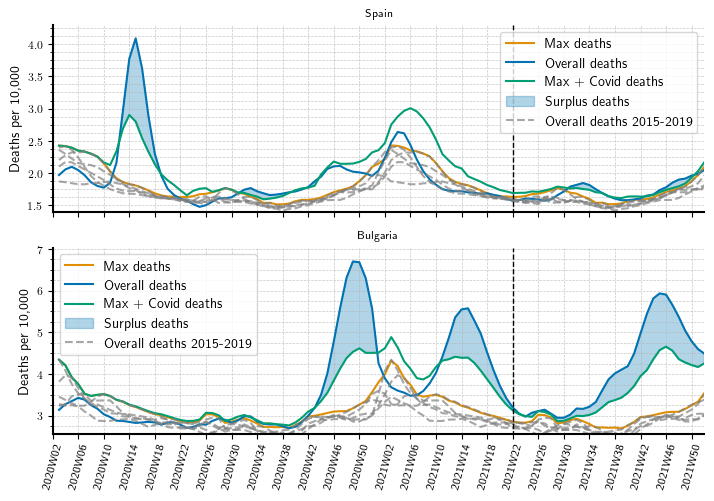

In [20]:

_, population = load_population()

deaths_prev_2020 = pd.read_csv('../results/deaths_correction_2020.csv', index_col=0)
deaths_prev_2021 = pd.read_csv('../results/deaths_correction_2020.csv', index_col=0)


def plot(to_plot, ax):
    last_week = to_plot.index[-3]
    last_week = '2021W52'

    to_plot = to_plot.loc[:last_week, :]
    to_plot.loc[:last_week, :].plot(ax=ax, grid=True, color=[colors[1], colors[0], colors[2]], linewidth=1.5)

    ax.fill_between(
        to_plot.index,
        to_plot['Overall deaths'],
        to_plot['Max deaths + Covid deaths (reported)'],
        where=to_plot['Overall deaths'] > to_plot['Max deaths + Covid deaths (reported)'],
        interpolate=True,
        color=colors[0],
        alpha=0.3
    )
    all_deaths = pd.concat([
        (deaths_prev_2020[deaths_prev_2020['Country'] == country].set_index('Year').drop(columns=['W53', 'Country']) / population.loc[country, 2021] * 10000).add_prefix('2020'),
        (deaths_prev_2021[deaths_prev_2021['Country'] == country].set_index('Year').drop(columns=['W53', 'Country']) / population.loc[country, 2021] * 10000).add_prefix('2021')
        ], axis=1).T
    all_deaths.rolling(window=3, min_periods=1).mean().loc['2020W03':].plot(ax=ax, color='grey', linestyle='--', linewidth=1.5, legend=False, alpha=0.7)
    ax.vlines('2021W22', 0, to_plot['Overall deaths'].max() * 1.05, linestyles='dashed', colors='black', linewidth=1)
    ax.set_ylim([to_plot['Overall deaths'].min() * 0.95, to_plot['Overall deaths'].max() * 1.05])

    ax.set_ylabel('Deaths per 10,000')
    ax.set_title(f'{country}')
    ax.set_xlabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.set_xticks([-1] + list(range(3, len(to_plot.index), 4)), ['2020W02'] + list(to_plot.index[3::4]), rotation=75)
    ax.set_xlim([-1, len(to_plot.index) - 1])
    # Increase the legend font size and set its position

    ax.legend(['Max deaths', 'Overall deaths', 'Max + Covid deaths', 'Surplus deaths', 'Overall deaths 2015-2019'], loc='best')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()

    return ax

fraction_per = 10000
fig, ax = plt.subplots(2, 1, figsize=(18.4*cm,13*cm))

country = 'Spain'


data = pd.read_csv('../results/CovidAndSurplusDeaths.csv').fillna(0)
data = data[data['Country'] == country].set_index('Date')
to_plot = pd.concat([data.loc[:, ['Max Deaths', 'Overall Deaths']], data.loc[:, ['Max Deaths', 'Covid Deaths']].sum(axis=1)], axis=1)
to_plot.columns = ['Max deaths', 'Overall deaths', 'Max deaths + Covid deaths (reported)']
to_plot = to_plot * fraction_per
ax1= plot(to_plot, ax[0])
ax1.set_xticklabels([])



country = 'Bulgaria'
data = pd.read_csv('../results/CovidAndSurplusDeaths.csv').fillna(0)
data = data[data['Country'] == country].set_index('Date')
to_plot = pd.concat([data.loc[:, ['Max Deaths', 'Overall Deaths']], data.loc[:, ['Max Deaths', 'Covid Deaths']].sum(axis=1)], axis=1)
to_plot.columns = ['Max deaths', 'Overall deaths', 'Max deaths + Covid deaths (reported)']
to_plot = to_plot * fraction_per
ax2 = plot(to_plot, ax[1])

plt.savefig(f'../figures/figure_S2 - Surplus.pdf')

### Syrplus deaths - European countries

C:\Users\macie\AppData\Local\Temp\ipykernel_109788\959128763.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  owid_excess_deaths = owid_excess_deaths.groupby(owid_excess_deaths.columns, axis=1).sum().apply(lambda x: np.maximum(x, 0) / 100)


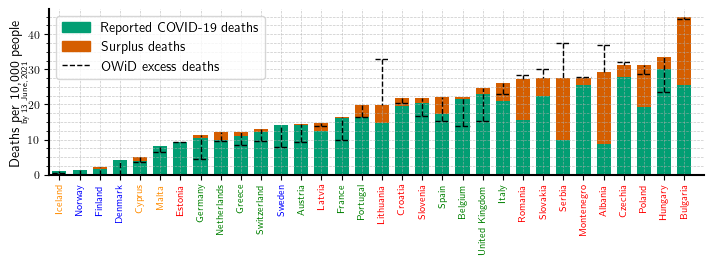

In [21]:

eu_countries = ["Sweden","Denmark","Finland","Norway","Austria","Belgium","France","Germany","United Kingdom","Switzerland","Netherlands","Greece","Italy","Portugal","Spain","Cyprus","Malta","Iceland","Albania","Bulgaria","Czechia","Croatia","Estonia","Poland","Romania","Serbia","Slovakia","Slovenia","Montenegro","Latvia","Lithuania","Hungary"]
owid_excess_deaths = pd.read_csv('https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv')
owid_excess_deaths = owid_excess_deaths.loc[:, ['country', 'date', 'excess_mortality_cumulative_per_million']].pivot(index='country', columns='date', values='excess_mortality_cumulative_per_million')
owid_excess_deaths.columns = pd.to_datetime(owid_excess_deaths.columns).strftime('%YW%U')

owid_excess_deaths = owid_excess_deaths.groupby(owid_excess_deaths.columns, axis=1).sum().apply(lambda x: np.maximum(x, 0) / 100)
fraction_per = 10000
data = pd.read_csv('../results/CovidAndSurplusDeaths.csv').fillna(0)
deaths = pd.concat([
    data.pivot(index='Country', columns='Date', values='Covid Deaths').cumsum(axis=1).loc[:, '2021W22'],
    data.pivot(index='Country', columns='Date', values='Surplus Deaths').cumsum(axis=1).loc[:, '2021W22'],
], axis=1)
deaths.columns = ['Reported covid deaths', 'gamma-extended deaths (gamma=1)']
deaths = deaths.rename(index={'Ireland': 'Ireland*', 'North Macedonia': 'North Macedonia*', 'Luxembourg': 'Luxembourg*'})
deaths.loc['Ireland*', 'gamma-extended deaths (gamma=1)'] = 0
deaths.loc[:, 'sum'] = deaths.sum(axis=1)
deaths = deaths[~deaths.index.str.contains('Liechtenstein')]

deaths = deaths * fraction_per
deaths = deaths.sort_values('sum', ascending=True)
deaths.loc[:, "Excess deaths (OWID)"] = owid_excess_deaths.loc[eu_countries, "2021W22"]
deaths = deaths.dropna()
deaths.loc[:, "Extended deaths (OWID)"] = deaths.loc[:, "Excess deaths (OWID)"]

fig, ax = plt.subplots(1, 1, figsize=(18.4*cm,7*cm))
bar_width = 0.35

for i, country in enumerate(deaths.index):
    ax.bar(i, deaths.loc[country, 'Reported covid deaths'], width=bar_width * 2, color=colors[2])
    ax.bar(i, deaths.loc[country, 'gamma-extended deaths (gamma=1)'], width=bar_width * 2, bottom=deaths.loc[country, 'Reported covid deaths'], color=colors[3])

for i, country in enumerate(deaths.index):
    ax.plot([i - bar_width, i + bar_width], [deaths.loc[country, 'Extended deaths (OWID)'], deaths.loc[country, 'Extended deaths (OWID)']], color='black', linestyle='--', linewidth=1)
    ax.plot([i, i], [deaths.loc[country, 'Extended deaths (OWID)'], deaths.loc[country, 'gamma-extended deaths (gamma=1)'] + deaths.loc[country, 'Reported covid deaths']], color='black', linestyle='--', linewidth=1)
ax.set_xticks(range(len(deaths.index)), deaths.index, rotation=90, fontsize=7)
ax.set_xlim([-0.5, len(deaths.index)])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set(xlabel='')
ax.set_ylabel('Deaths per 10,000 people')
ax.text(-0.037, 0.5, "by 13 June, 2021", ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=6)

ax.title.set_size(20)
handles, labels = ax.get_legend_handles_labels()

handles.append(mpatches.Patch(color=colors[2], label='Reported COVID-19 deaths')) 
handles.append(mpatches.Patch(color=colors[3], label='Surplus deaths')) 
handles.append(Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='OWiD excess deaths')) 
ax.legend(handles=handles, loc='best')

ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
for i, label in enumerate(ax.get_xticklabels()):
    try:
        label.set_color(countries_colors[label.get_text()])
    except:
        pass
plt.tight_layout()
plt.savefig(f'../figures/figure_S3 - Extended deaths.pdf')

### Prevalence

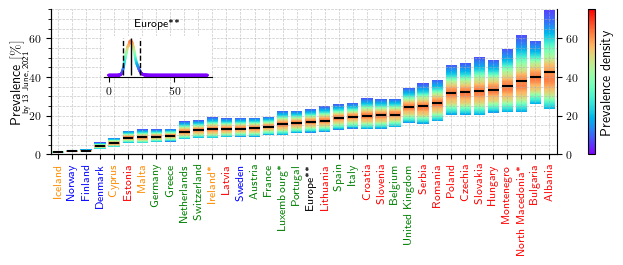

In [22]:
ci = 0.975
gamma = 0.85

prevalence = pd.read_csv(f'../results/prevalence_vectors/Prevalence2021W22({gamma=}).csv', index_col=0).T
prevalence = prevalence.rename(index={'Ireland': 'Ireland*', 'North Macedonia': 'North Macedonia*', 'Luxembourg': 'Luxembourg*'})
hist_bins = 500
hist_range = (0, 75)

fig, ax = plt.subplots(1, 1, figsize=(18.4*cm,7*cm))

cmap = plt.cm.rainbow

removed_countries = 0
for i, country in enumerate(prevalence.median(axis=1).sort_values().index):
    i -= removed_countries
    if country not in countries_colors.keys():
        removed_countries += 1
        continue
    prev = prevalence.loc[country, :]

    kde = gaussian_kde(prev)
    bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
    hist_values = kde(bin_edges)

    norm = mcolors.Normalize(vmin=0, vmax=hist_values.max() * 1.2)
    hist_values_normalized = norm(hist_values)

    lower_bound = prev.quantile(1 - ci)
    upper_bound = prev.quantile(ci)

    for j in range(hist_bins):
        if bin_edges[j] > upper_bound:
            break
        if bin_edges[j] < lower_bound:
            continue
        ax.bar(
            i, 
            bin_edges[j + 1] - bin_edges[j],
            bottom=bin_edges[j],
            width=0.8, 
            color=cmap(hist_values_normalized[j]),
            edgecolor='none'
        )
    
    median = prev.median()
    lower_bound = prev.quantile(1 - ci)
    upper_bound = prev.quantile(ci)
    
    ax.plot(
        [i - 0.3, i + 0.3],
        [median, median],
        color='black',
        linestyle='-',
        zorder=5
    )

ax.set_xlabel('')
ax.set_ylabel(r'Prevalence $[\%]$')
ax.text(-0.048, 0.5, "by 13 June, 2021", ha='center', va='center', transform=ax.transAxes, rotation=90, fontsize=6)

# ax.set_title(f'Prevalence {round(1 - ci, 2)} and {round(ci, 2)} quantiles')

ax.set_ylim(hist_range)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2 = ax.twinx()
ax2.set_ylim(hist_range)
ax2.spines['right'].set_visible(True)
ax2.yaxis.set_tick_params(which='both', direction='out')
ax2.yaxis.set_label_position('right')
ax.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
labels = [label for label in prevalence.median(axis=1).sort_values().index if label in countries_colors.keys()]
ax.set_xlim([-0.5, len(labels) - 0.5])
ax.set_xticks(range(len(labels)), labels, rotation=90)
plt.tight_layout()




ax_inset = fig.add_axes([0.15, 0.7, 0.15, 0.15])  # [left, bottom, width, height]
country = 'Europe**'
prev = prevalence.loc[country, :]

kde = gaussian_kde(prev)
bin_edges = np.linspace(*hist_range, hist_bins)
hist_values = kde(bin_edges)
norm = mcolors.Normalize(vmin=0, vmax=hist_values.max() * 1.2)
hist_values_normalized = norm(hist_values)
ax_inset.scatter(bin_edges, hist_values, color=cmap(hist_values_normalized), s=1)
ax_inset.vlines(prev.median(), 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='-')
ax_inset.vlines(prev.quantile(1-ci), 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='--')
ax_inset.vlines(prev.quantile(ci), 0, hist_values.max() * 1.1, color='black', linewidth=1, linestyle='--')
ax_inset.set_title(country)
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)
ax_inset.spines['left'].set_visible(False)
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_inset.set_yticks([])
for i, label in enumerate(ax.get_xticklabels()):
    try:
        label.set_color(countries_colors[label.get_text()])
    except:
        pass
# ax.legend(['Median',], loc='best')
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=[])
cbar.set_label('Prevalence density')

plt.savefig(f'../figures/figure_S4 - Prevalence density.pdf', bbox_inches='tight')
plt.show()


### Ranking

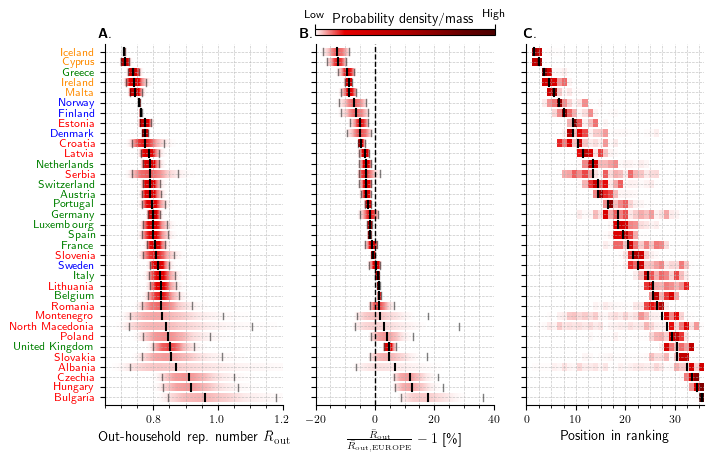

In [23]:
plt.rcParams['text.usetex'] = True
ci = 0.975
gamma = 0.85

# Load data
r_val = pd.read_csv(f'../results/CValues.csv', index_col=0).T
r_val = pd.read_csv('../results/processed/(gamma=0.85,ah=0.2,europe_as_country)_data_c.csv', index_col=0).T
hist_bins = 500
hist_range = (0.65, 1.2)
rankings = r_val.rank()

prevalence = r_val
data = pd.read_csv('../results/processed/EUmeans/(gamma=0.85,ah=0.2)_EUmeans.csv', index_col=0).T.loc["europe_as_country", :]
prevalence = (prevalence / data - 1) * 100
hist_range2 = (-20, 40)


# Get the sorted list of countries
countries = r_val.median(axis=1).sort_values(ascending=False).index
num_countries = len(countries)

# Create a figure with two subplots sharing the y-axis
fig, axes = plt.subplots(1, 3, figsize=(18.4*cm,13*cm))
ax1, ax2, ax3 = axes


cmap_colors = [(1, 1, 1), (0.9, 0.0, 0.0), (0.8, 0, 0), (0.7, 0, 0), (0.55, 0, 0), (0.4, 0, 0), (0.3, 0, 0)]  # from white to dark red
n_bins = 1000  # number of bins for color interpolation
cmap_name = 'custom_red'

# Create the colormap
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, cmap_colors, N=n_bins)
cmap3 = custom_cmap
cmap1 = custom_cmap
cmap2 = custom_cmap

# Plotting function to avoid repetition
def plot_horizontal_bar(ax, data, index, hist_range, hist_bins, ci, kde_enabled=True, shift_median=0, cmap=cmap1, max_hist=None):
    prev = data
    if kde_enabled:
        kde = gaussian_kde(prev)
        bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
        hist_values = kde(bin_edges)
        norm = mcolors.Normalize(vmin=0.01, vmax=max_hist if max_hist < 100 else 100)
    else:
        hist_values, _ = np.histogram(prev, bins=hist_bins, range=hist_range)
        bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
        norm = mcolors.Normalize(vmin=0, vmax=len(prev))

    
    hist_values_normalized = norm(hist_values)
    lower_bound = prev.quantile(1 - ci)
    upper_bound = prev.quantile(ci)

    # Plot horizontal bars
    for j in range(hist_bins):
        # if bin_edges[j] > upper_bound and not lower_bound == upper_bound:
        #     break
        # if bin_edges[j] < lower_bound and not lower_bound == upper_bound:
        #     continue
        try:
            delta = bin_edges[j + 1] - bin_edges[j]
        except:
            pass
        ax.barh(
            index,
            delta,
            left=bin_edges[j],
            height=0.8,
            color=cmap(hist_values_normalized[j]),
            edgecolor='none'
        )
    median = prev.median()
    # Plot median line
    ax.plot(
        [median + shift_median, median + shift_median],
        [index - 0.32, index + 0.34],
        color='black',
        linestyle='-',
        zorder=5
    )
    if kde_enabled:
        ax.plot(
            [lower_bound + shift_median, lower_bound + shift_median],
            [index - 0.32, index + 0.34],
            color='black',
            linestyle='-',
            zorder=5,
            alpha=0.5,
            linewidth=1
        )
        ax.plot(
            [upper_bound + shift_median, upper_bound + shift_median],
            [index - 0.32, index + 0.34],
            color='black',
            linestyle='-',
            zorder=5,
            alpha=0.5,
            linewidth=1
        )
        
max_1, max_2 = 0, 0
for country in countries:
    kde = gaussian_kde(r_val.loc[country, :])
    bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
    hist_values = kde(bin_edges)
    max_1 = hist_values.max() if hist_values.max() > max_1 else max_1

    kde = gaussian_kde(prevalence.loc[country, :])
    bin_edges = np.linspace(hist_range[0], hist_range[1], hist_bins)
    hist_values = kde(bin_edges)
    max_2 = hist_values.max() if hist_values.max() > max_2 else max_2


for i, country in enumerate(countries):
    prev = r_val.loc[country, :]
    plot_horizontal_bar(ax1, prev, i, hist_range, 500, ci=ci, cmap=cmap1, max_hist=max_1)
    prev = prevalence.loc[country, :]
    plot_horizontal_bar(ax2, prev, i, hist_range2, 500, ci=ci, cmap=cmap2, max_hist=max_2)
    rank = rankings.loc[country, :]
    plot_horizontal_bar(ax3, rank, i, (0, num_countries), num_countries, ci=1, kde_enabled=False, shift_median=0.5, cmap=cmap3)  # Assuming same data for both plots

ax2.vlines(0, -0.75, num_countries - 0.25, linestyles='dashed', colors='black', linewidth=1)

ax1.set_yticks(range(num_countries), countries)
ax2.set_yticks(range(num_countries), [])
ax3.set_yticks(range(num_countries), [])


ax1.set_xlabel(r'Out-household rep. number $\bar R_{\rm out}$')
ax2.set_xlabel(r'$\frac{\bar{R}_{\rm out}}{\bar{R}_{\rm out,EUROPE}} - 1$ [\%]')
ax3.set_xlabel(r'Position in ranking')

ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

ax1.set_ylim([-0.75, num_countries - 0.25])
ax2.set_ylim([-0.75, num_countries - 0.25])
ax3.set_ylim([-0.75, num_countries - 0.25])
ax1.set_xlim(hist_range)
ax2.set_xlim(hist_range2)
ax3.set_xlim([0, num_countries + 1])
ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
ax3.xaxis.set_minor_locator(AutoMinorLocator(4))
# ax2.set_xscale('symlog', linthresh=1)
# Adjust layout
plt.tight_layout()


cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap3, norm=mcolors.Normalize(vmin=0, vmax=1)), ax=axes, orientation='horizontal', ticks=[0, 1], location='top', pad=0.02, aspect=30, shrink=0.3)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xticklabels(['Low', 'High'])
cbar.set_label('Probability density/mass', labelpad=-10)
cbar.ax.xaxis.set_label_position('top')

ax1.text(0.65, 35.7, r'\textbf{A}.', ha='center', va='center')
ax2.text(-23, 35.7, r'\textbf{B}.', ha='center', va='center')
ax3.text(0.6, 35.7, r'\textbf{C}.', ha='center', va='center')


for i, label in enumerate(ax1.get_yticklabels()):
    try:
        label.set_color(countries_colors[label.get_text()])
    except:
        pass
# v1 - Value threshold for the distribution. Max value is 100
plt.savefig(f'../figures/figure_3 - Ranking.pdf', bbox_inches='tight')

### Gamma

0.8134210681318327


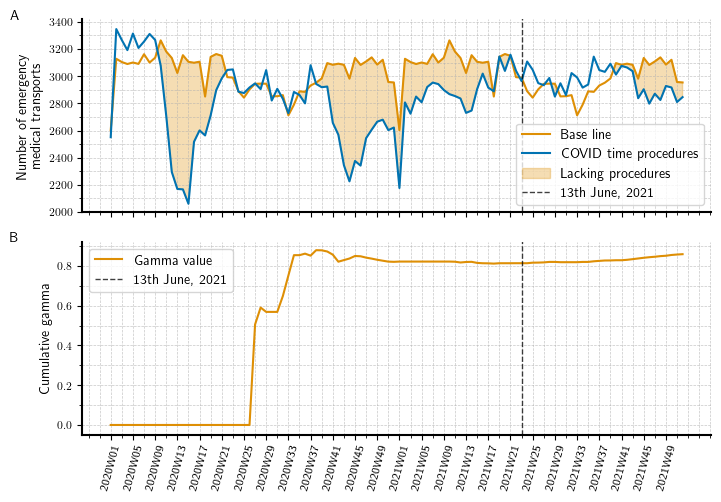

In [24]:
df = pd.read_excel('../data/PolandUrgentMedicalInterventions.xlsx', sheet_name='For_Tyll')
df.columns = ['Year', 'Week', 'Heart procedures', 'Stroke', 'Broken bones', 'Heart attack', 'Sum']
df = df.drop(columns=['Broken bones', 'Sum'])
df.loc[:, 'Sum'] = df.loc[:, ['Heart procedures', 'Stroke', 'Heart attack']].sum(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18.4*cm,13*cm))

# Calculations
values_column = 'Sum'
dfp = df.pivot(index='Year', columns='Week', values=values_column)
dfp = dfp.fillna(0)

base_line_max = dfp.loc[:2019, :52].rolling(window=3, min_periods=1, center=True).mean().max(axis=0)
base_line_min = dfp.loc[:2019, :52].rolling(window=3, min_periods=1, center=True).mean().min(axis=0)
base_line_mean = dfp.loc[:2019, :52].rolling(window=3, min_periods=1, center=True).mean().mean(axis=0)


base_line = base_line_mean
base_line_2020 = base_line.copy()
base_line_2021 = base_line.copy()
base_line_2020.index = [f'2020W{x:02d}' for x in base_line_2020.index]
base_line_2021.index = [f'2021W{x:02d}' for x in base_line_2021.index]
base_line_to_plot = pd.concat([base_line_2020, base_line_2021], axis=0)

lacking_procedures = (base_line - dfp.loc[2020:, :52]).apply(lambda x: np.maximum(x, 0))
lacking_procedures = lacking_procedures.T.shift(1, fill_value=0).T # Shift the data by one week
lp_2020 = lacking_procedures.loc[2020, :52]
lp_2021 = lacking_procedures.loc[2021, :52]
lp_2020.index = [f'2020W{x:02d}' for x in lp_2020.index]
lp_2021.index = [f'2021W{x:02d}' for x in lp_2021.index]
lacking_procedures = pd.concat([lp_2020, lp_2021], axis=0)
lacking_procedures = lacking_procedures.to_frame().T

sp_2020 = dfp.loc[2020, :52]
sp_2021 = dfp.loc[2021, :52]
sp_2020.index = [f'2020W{x:02d}' for x in sp_2020.index]
sp_2021.index = [f'2021W{x:02d}' for x in sp_2021.index]
procedures = pd.concat([sp_2020, sp_2021], axis=0)

# Ploting

base_line_to_plot.plot(ax=ax1, color=colors[1])
procedures.plot(ax=ax1, color=colors[0])

ax1.fill_between(
    base_line_to_plot.index,
    procedures,
    base_line_to_plot,
    where=procedures < base_line_to_plot,
    interpolate=True,
    alpha=0.3,
    color=colors[1]
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_linewidth(1.5)
ax1.set(
    ylabel='Number of emergency\nmedical transports',
    xlabel='',
    title=""
    )
ax1.vlines(base_line_to_plot.index.get_loc('2021W23'), 1900, 3500, linestyles='dashed', colors='black', linewidth=1, alpha=0.75)

ax1.legend(["Base line", 'COVID time procedures', 'Lacking procedures', '13th June, 2021'], loc='lower right')

ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_xticks(range(0, len(base_line_to_plot.index), 4), ['' for x in base_line_to_plot.index[::4]])

ax1.set_ylim(2000, 3420)


ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.tight_layout()
# plt.savefig(f'../results/charts/S2 - Surplus procedures {values_column} MEAN window=3 shift=1.pdf')



from load_dataset import load_covid_deaths, load_deaths, load_population
from excess_deaths import calculate_max_deaths

window = 1

# Load the data
CIFR = pd.read_csv('../results/CIFRVectors.csv', index_col=0)
_, population = load_population()
deaths = load_deaths()
covid_deaths = load_covid_deaths()

# Remove countries with no available data
common_countries = ['Poland']
CIFR = CIFR.loc[:, common_countries]
population = population.loc[common_countries, :]
deaths = deaths.loc[(slice(None), common_countries), :]
deaths = deaths.reset_index().groupby(['Year', 'Country']).sum()
covid_deaths = covid_deaths.loc[common_countries, :].T.rolling(window=window, min_periods=1).mean().T

# Calculate max deaths line
max_deaths = calculate_max_deaths(deaths.loc[(slice('2015', '2019'), slice(None)), :], population)
max_deaths = max_deaths.T.rolling(window=window, min_periods=1).mean().T

# Claculate surplus deaths
overall_deaths = pd.concat([
    deaths.loc[('2020', slice(None)), :].add_prefix('2020').reset_index(level=0, drop=True),
    deaths.loc[('2021', slice(None)), :].add_prefix('2021').reset_index(level=0, drop=True)
    ], axis=1).fillna(0)
overall_deaths = overall_deaths.T.rolling(window=window, min_periods=1).mean().T
surplus_deaths = np.maximum(np.maximum(overall_deaths - max_deaths, 0) - covid_deaths, 0).fillna(0)
surplus_deaths = surplus_deaths.loc[:, lacking_procedures.columns]
print(np.maximum(surplus_deaths.loc['Poland', :] - lacking_procedures.loc[0, :], 0).cumsum().loc['2021W22'] / surplus_deaths.loc['Poland', :].cumsum().loc['2021W22'])

(np.maximum(surplus_deaths.loc['Poland', :] - lacking_procedures.loc[0, :], 0).cumsum() / surplus_deaths.loc['Poland', :].cumsum()).fillna(0).plot(ax=ax2, color=colors[1])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['bottom'].set_linewidth(1.5)
ax2.set(
    xlabel='',
    title=""
    )
ax2.set_ylabel('Cumulative gamma')

ax2.vlines(base_line_to_plot.index.get_loc('2021W23'), -0.05, 1, linestyles='dashed', colors='black', linewidth=1, alpha=0.75)
# ax.legend(["Gamma"], fontsize=14)
ax2.legend(['Gamma value', '13th June, 2021'])
ax2.set_xticks(range(0, len(base_line_to_plot.index), 4), list(base_line_to_plot.index[::4]), rotation=75)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2.xaxis.set_minor_locator(AutoMinorLocator(2))

ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, fontweight="bold", va="top", ha="right")
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, fontweight="bold", va="top", ha="right")

ax2.set_ylim(-0.05, 0.92)
plt.tight_layout()
plt.savefig(f'../figures/figure_S5 - Gamma estimates.pdf')